1. 확률 (Probability) 계산
질문: 정규분포 N(0,1)에서 -0.95 ~ 0.95 사이에 샘플이 나올 확률은?
답변: 이것은 확률입니다!

Probability (using CDF): P(-0.95 ≤ X ≤ 0.95 | μ=0, σ=1) = 0.6579
Probability (using integration): 0.6579

→ 파라미터(μ, σ)는 고정, 구간은 변수

[그래프 저장됨: probability_example.png]


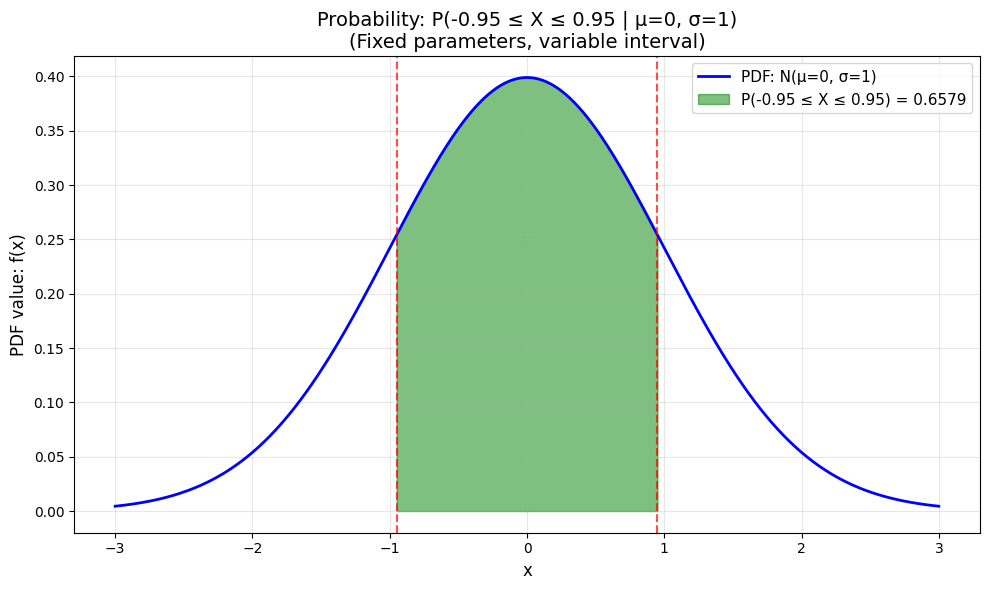

In [1]:
"""
Likelihood (가능도) vs Probability (확률) 비교

핵심 차이:
- 확률(Probability): 파라미터 고정 → 구간에 대한 확률 계산
- 가능도(Likelihood): 데이터 고정 → 파라미터에 대한 가능성 계산
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy import integrate

# Set figure size
plt.rcParams['figure.figsize'] = (10, 6)


# ============================================
# 1. 확률 (Probability) 계산
# ============================================
print("="*70)
print("1. 확률 (Probability) 계산")
print("="*70)
print("질문: 정규분포 N(0,1)에서 -0.95 ~ 0.95 사이에 샘플이 나올 확률은?")
print("답변: 이것은 확률입니다!\n")

mu_true = 0
sigma_true = 1

# Method 1: Using CDF
prob_cdf = norm.cdf(0.95, loc=mu_true, scale=sigma_true) - norm.cdf(-0.95, loc=mu_true, scale=sigma_true)
print(f"Probability (using CDF): P(-0.95 ≤ X ≤ 0.95 | μ={mu_true}, σ={sigma_true}) = {prob_cdf:.4f}")

# Method 2: Using integration
prob_integral, _ = integrate.quad(
    lambda x: norm.pdf(x, loc=mu_true, scale=sigma_true), 
    -0.95, 0.95
)
print(f"Probability (using integration): {prob_integral:.4f}")

print("\n→ 파라미터(μ, σ)는 고정, 구간은 변수")
print("="*70)

# Visualization: Probability
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
x_range = np.linspace(-3, 3, 1000)
pdf_curve = norm.pdf(x_range, loc=mu_true, scale=sigma_true)

# Plot PDF curve
ax.plot(x_range, pdf_curve, 'b-', linewidth=2, label=f'PDF: N(μ={mu_true}, σ={sigma_true})')

# Highlight the interval [-0.95, 0.95]
interval_range = np.linspace(-0.95, 0.95, 100)
interval_pdf = norm.pdf(interval_range, loc=mu_true, scale=sigma_true)
ax.fill_between(interval_range, 0, interval_pdf, alpha=0.5, color='green',
                label=f'P(-0.95 ≤ X ≤ 0.95) = {prob_cdf:.4f}')

ax.axvline(x=-0.95, color='r', linestyle='--', alpha=0.7, linewidth=1.5)
ax.axvline(x=0.95, color='r', linestyle='--', alpha=0.7, linewidth=1.5)
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('PDF value: f(x)', fontsize=12)
ax.set_title('Probability: P(-0.95 ≤ X ≤ 0.95 | μ=0, σ=1)\n(Fixed parameters, variable interval)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('probability_example.png', dpi=150, bbox_inches='tight')
print("\n[그래프 저장됨: probability_example.png]")
plt.show()



2. 가능도 (Likelihood) 계산
질문: 데이터가 주어졌을 때, μ=0, σ=1에 대한 가능도는?
답변: 이것은 가능도입니다!

Observed data: [-0.32229897 -1.63772213 -2.07126717 -1.54426954 -1.75919504 -0.04563365
 -0.35457487  0.38068998 -1.38214108 -0.02748628]

Likelihood for μ=0, σ=1:
  - Likelihood: 6.433692e-08
  - Log-likelihood: -16.5591

Likelihood for μ=0.5, σ=1.2:
  - Likelihood: 1.977254e-09
  - Log-likelihood: -20.0416

→ 데이터는 고정, 파라미터(μ, σ)는 변수

[그래프 저장됨: likelihood_example.png]


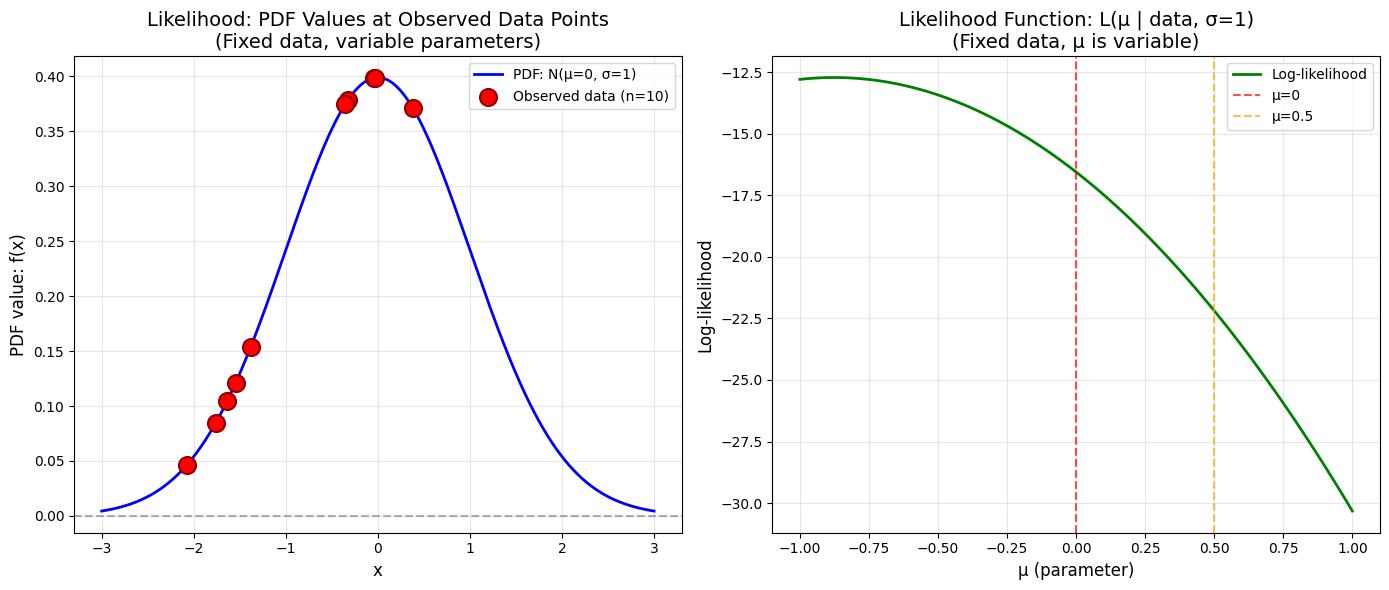

In [2]:
# ============================================
# 2. 가능도 (Likelihood) 계산
# ============================================
print("\n" + "="*70)
print("2. 가능도 (Likelihood) 계산")
print("="*70)
print("질문: 데이터가 주어졌을 때, μ=0, σ=1에 대한 가능도는?")
print("답변: 이것은 가능도입니다!\n")

# Generate observed data from N(0, 1)
# np.random.seed(43052)
observed_data = np.random.normal(0, 1, size=10)
print(f"Observed data: {observed_data}\n")

def likelihood_normal(data, mu, sigma):
    """
    Calculate likelihood: L(μ, σ | data) = ∏ f(x_i | μ, σ)
    """
    # Use log-likelihood to avoid numerical underflow
    log_likelihood = np.sum(norm.logpdf(data, loc=mu, scale=sigma))
    return np.exp(log_likelihood), log_likelihood

# Likelihood for true parameters (μ=0, σ=1)
mu_candidate = 0
sigma_candidate = 1
likelihood, log_likelihood = likelihood_normal(observed_data, mu_candidate, sigma_candidate)
print(f"Likelihood for μ={mu_candidate}, σ={sigma_candidate}:")
print(f"  - Likelihood: {likelihood:.6e}")
print(f"  - Log-likelihood: {log_likelihood:.4f}")

# Likelihood for different parameters
mu_candidate2 = 0.5
sigma_candidate2 = 1.2
likelihood2, log_likelihood2 = likelihood_normal(observed_data, mu_candidate2, sigma_candidate2)
print(f"\nLikelihood for μ={mu_candidate2}, σ={sigma_candidate2}:")
print(f"  - Likelihood: {likelihood2:.6e}")
print(f"  - Log-likelihood: {log_likelihood2:.4f}")

print("\n→ 데이터는 고정, 파라미터(μ, σ)는 변수")
print("="*70)

# Visualization: Likelihood
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: PDF values at observed data points
x_range = np.linspace(-3, 3, 1000)
pdf_curve = norm.pdf(x_range, loc=mu_candidate, scale=sigma_candidate)
pdf_at_points = norm.pdf(observed_data, loc=mu_candidate, scale=sigma_candidate)

ax1.plot(x_range, pdf_curve, 'b-', linewidth=2, label=f'PDF: N(μ={mu_candidate}, σ={sigma_candidate})')
ax1.scatter(observed_data, pdf_at_points, color='red', s=150, zorder=5, marker='o',
           edgecolors='darkred', linewidths=1.5, label=f'Observed data (n={len(observed_data)})')
ax1.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('PDF value: f(x)', fontsize=12)
ax1.set_title('Likelihood: PDF Values at Observed Data Points\n(Fixed data, variable parameters)', fontsize=14)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Right: Likelihood as function of μ
mu_range = np.linspace(-1, 1, 100)
likelihoods = []
for mu_test in mu_range:
    _, log_lik = likelihood_normal(observed_data, mu_test, sigma_candidate)
    likelihoods.append(log_lik)

ax2.plot(mu_range, likelihoods, 'g-', linewidth=2, label='Log-likelihood')
ax2.axvline(x=mu_candidate, color='r', linestyle='--', alpha=0.7, label=f'μ={mu_candidate}')
ax2.axvline(x=mu_candidate2, color='orange', linestyle='--', alpha=0.7, label=f'μ={mu_candidate2}')
ax2.set_xlabel('μ (parameter)', fontsize=12)
ax2.set_ylabel('Log-likelihood', fontsize=12)
ax2.set_title('Likelihood Function: L(μ | data, σ=1)\n(Fixed data, μ is variable)', fontsize=14)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('likelihood_example.png', dpi=150, bbox_inches='tight')
print("\n[그래프 저장됨: likelihood_example.png]")
plt.show()


In [3]:
# ============================================
# 3. 내부 계산 과정: logpdf가 어떻게 동작하는가?
# ============================================
print("\n" + "="*70)
print("3. 내부 계산 과정: np.sum(norm.logpdf(data, loc=mu, scale=sigma))")
print("="*70)

# Sample data
sample_data = observed_data[:3]
mu = 0
sigma = 1

print(f"\n데이터: {sample_data}")
print(f"파라미터: μ={mu}, σ={sigma}\n")

# Step 1: 각 데이터 포인트에 대한 logpdf 계산
logpdf_values = norm.logpdf(sample_data, loc=mu, scale=sigma)
print("Step 1: 각 점에서의 logpdf 값:")
for i, (x, logpdf_val) in enumerate(zip(sample_data, logpdf_values)):
    print(f"  log f({x:.4f} | μ={mu}, σ={sigma}) = {logpdf_val:.6f}")

# Step 2: 수동 계산 (내부 동작 확인)
def manual_logpdf(x, mu, sigma):
    """
    Manual calculation: log f(x | μ, σ) = -log(σ) - 0.5*log(2π) - 0.5*((x-μ)/σ)²
    """
    constant = -np.log(sigma) - 0.5 * np.log(2 * np.pi)
    quadratic = -0.5 * ((x - mu) / sigma) ** 2
    return constant + quadratic

print("\nStep 2: 수동 계산 결과:")
for x, scipy_val in zip(sample_data, logpdf_values):
    manual_val = manual_logpdf(x, mu, sigma)
    print(f"  x={x:.4f}: scipy={scipy_val:.6f}, manual={manual_val:.6f}")

# Step 3: 합산
print(f"\nStep 3: 모든 logpdf 값들의 합산")
print(f"  Log-likelihood = {logpdf_values[0]:.6f} + {logpdf_values[1]:.6f} + {logpdf_values[2]:.6f} + ...")
print(f"  = {np.sum(logpdf_values):.6f}")

# Full data
full_logpdf = norm.logpdf(observed_data, loc=mu, scale=sigma)
full_log_likelihood = np.sum(full_logpdf)
print(f"\n전체 데이터({len(observed_data)}개)에 대한 log-likelihood: {full_log_likelihood:.6f}")
print("="*70)



3. 내부 계산 과정: np.sum(norm.logpdf(data, loc=mu, scale=sigma))

데이터: [-0.32229897 -1.63772213 -2.07126717]
파라미터: μ=0, σ=1

Step 1: 각 점에서의 logpdf 값:
  log f(-0.3223 | μ=0, σ=1) = -0.970877
  log f(-1.6377 | μ=0, σ=1) = -2.260005
  log f(-2.0713 | μ=0, σ=1) = -3.064012

Step 2: 수동 계산 결과:
  x=-0.3223: scipy=-0.970877, manual=-0.970877
  x=-1.6377: scipy=-2.260005, manual=-2.260005
  x=-2.0713: scipy=-3.064012, manual=-3.064012

Step 3: 모든 logpdf 값들의 합산
  Log-likelihood = -0.970877 + -2.260005 + -3.064012 + ...
  = -6.294895

전체 데이터(10개)에 대한 log-likelihood: -16.559132



4. 연속 확률분포: 확률 vs PDF 값

예시: x = 0.5
1. P(X = 0.5) = 0 (연속 분포에서는 확률이 0!) ✅
2. f(0.5 | μ=0, σ=1) = 0.352065 (PDF 값, 0이 아님!)
3. P(0.49 ≤ X ≤ 0.51) = 0.007041 (0이 아님!)

→ Likelihood에서 사용하는 것은 PDF 값 f(x)입니다!
  → 이것은 확률이 아니라 PDF 함수의 높이(값)입니다.

[그래프 저장됨: pdf_vs_probability.png]


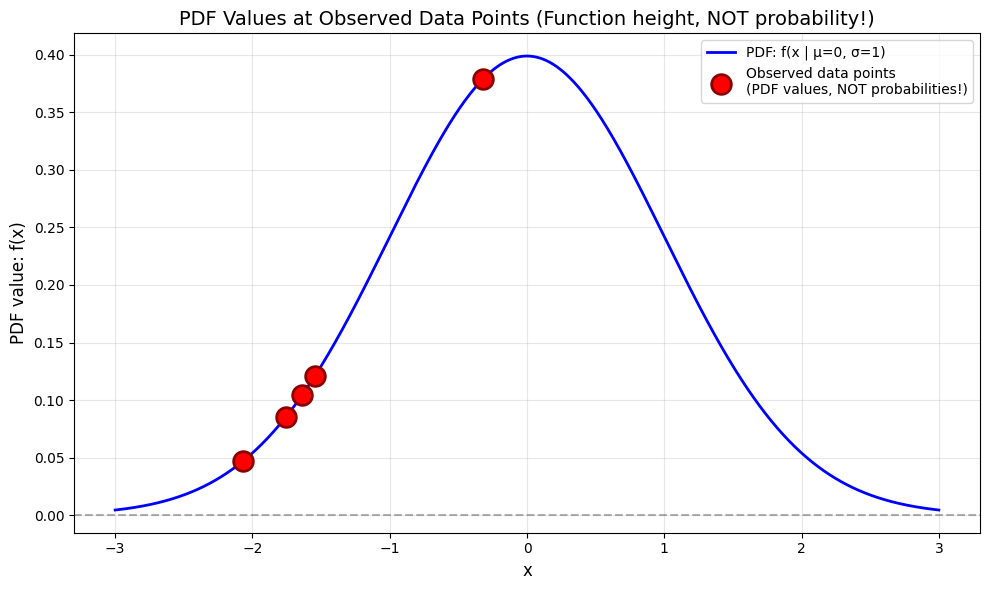

In [4]:

# ============================================
# 4. 연속 확률분포: 확률 vs PDF 값
# ============================================
print("\n" + "="*70)
print("4. 연속 확률분포: 확률 vs PDF 값")
print("="*70)

x_example = 0.5
print(f"\n예시: x = {x_example}")

# 특정 점에서의 확률
print(f"1. P(X = {x_example}) = 0 (연속 분포에서는 확률이 0!) ✅")

# PDF 값
pdf_value = norm.pdf(x_example, loc=mu, scale=sigma)
print(f"2. f({x_example} | μ={mu}, σ={sigma}) = {pdf_value:.6f} (PDF 값, 0이 아님!)")

# 작은 구간에서의 확률
epsilon = 0.01
prob_interval = norm.cdf(x_example+epsilon, loc=mu, scale=sigma) - norm.cdf(x_example-epsilon, loc=mu, scale=sigma)
print(f"3. P({x_example-epsilon:.2f} ≤ X ≤ {x_example+epsilon:.2f}) = {prob_interval:.6f} (0이 아님!)")

print("\n→ Likelihood에서 사용하는 것은 PDF 값 f(x)입니다!")
print("  → 이것은 확률이 아니라 PDF 함수의 높이(값)입니다.")
print("="*70)

# Visualization: PDF value vs Probability
fig, ax1 = plt.subplots(1, 1, figsize=(10, 6))

# PDF curve with observed points
x_range = np.linspace(-3, 3, 1000)
pdf_curve = norm.pdf(x_range, loc=mu, scale=sigma)
observed_points = observed_data[:5]  # Show first 5 points
pdf_at_points = norm.pdf(observed_points, loc=mu, scale=sigma)

ax1.plot(x_range, pdf_curve, 'b-', linewidth=2, label='PDF: f(x | μ=0, σ=1)')
ax1.scatter(observed_points, pdf_at_points, color='red', s=200, zorder=5, marker='o',
           edgecolors='darkred', linewidths=2, label='Observed data points\n(PDF values, NOT probabilities!)')
ax1.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('PDF value: f(x)', fontsize=12)
ax1.set_title('PDF Values at Observed Data Points (Function height, NOT probability!)', fontsize=14)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pdf_vs_probability.png', dpi=150, bbox_inches='tight')
print("\n[그래프 저장됨: pdf_vs_probability.png]")
plt.show()


5. 요약

확률 (Probability):
  - 파라미터(μ, σ) 고정 → 구간에 대한 확률 계산
  - 예: P(-0.95 ≤ X ≤ 0.95 | μ=0, σ=1)

가능도 (Likelihood):
  - 데이터 고정 → 파라미터에 대한 가능성 계산
  - L(μ, σ | data) = ∏ f(x_i | μ, σ)
  - 각 점에서의 PDF 값(함수의 높이)들의 곱

핵심:
  - 연속 분포에서 P(X = x) = 0
  - 하지만 PDF 값 f(x) ≠ 0
  - Likelihood는 PDF 값들을 사용 (확률이 아님!)


최종 비교 그래프 생성 중...
[그래프 저장됨: comparison_summary.png]


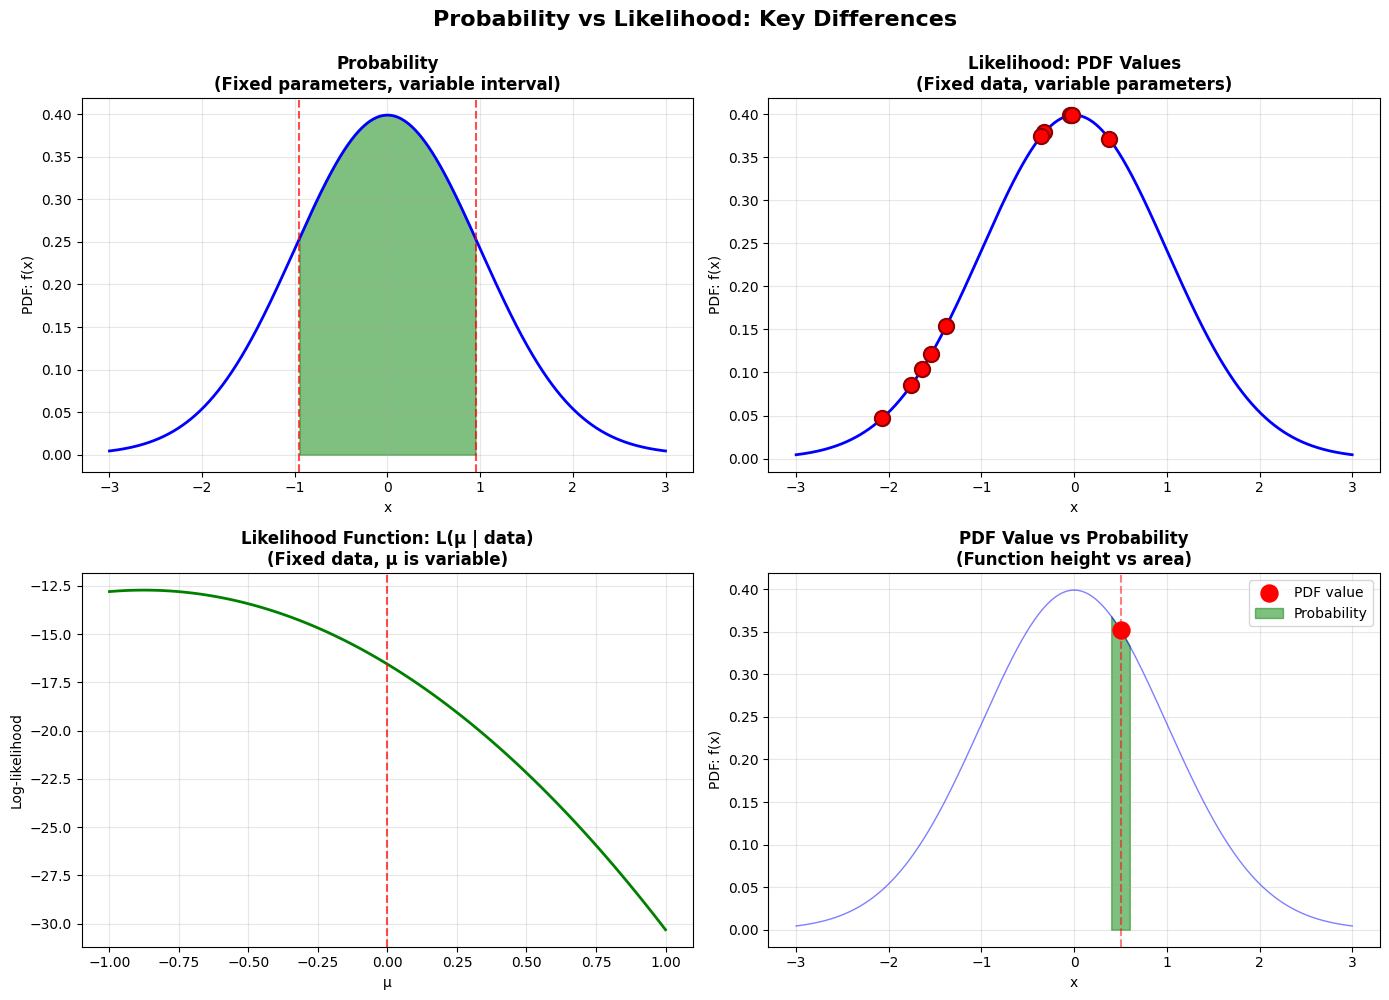

In [5]:
# ============================================
# 5. 요약
# ============================================
print("\n" + "="*70)
print("5. 요약")
print("="*70)
print("""
확률 (Probability):
  - 파라미터(μ, σ) 고정 → 구간에 대한 확률 계산
  - 예: P(-0.95 ≤ X ≤ 0.95 | μ=0, σ=1)

가능도 (Likelihood):
  - 데이터 고정 → 파라미터에 대한 가능성 계산
  - L(μ, σ | data) = ∏ f(x_i | μ, σ)
  - 각 점에서의 PDF 값(함수의 높이)들의 곱

핵심:
  - 연속 분포에서 P(X = x) = 0
  - 하지만 PDF 값 f(x) ≠ 0
  - Likelihood는 PDF 값들을 사용 (확률이 아님!)
""")
print("="*70)

# Final comparison visualization
print("\n최종 비교 그래프 생성 중...")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Probability: Fixed parameters, variable interval
x_range = np.linspace(-3, 3, 1000)
pdf_curve = norm.pdf(x_range, loc=0, scale=1)
interval_range = np.linspace(-0.95, 0.95, 100)
interval_pdf = norm.pdf(interval_range, loc=0, scale=1)

axes[0, 0].plot(x_range, pdf_curve, 'b-', linewidth=2)
axes[0, 0].fill_between(interval_range, 0, interval_pdf, alpha=0.5, color='green')
axes[0, 0].axvline(x=-0.95, color='r', linestyle='--', alpha=0.7)
axes[0, 0].axvline(x=0.95, color='r', linestyle='--', alpha=0.7)
axes[0, 0].set_title('Probability\n(Fixed parameters, variable interval)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('x')
axes[0, 0].set_ylabel('PDF: f(x)')
axes[0, 0].grid(True, alpha=0.3)

# 2. Likelihood: Fixed data, variable parameters
pdf_at_obs = norm.pdf(observed_data, loc=0, scale=1)
axes[0, 1].plot(x_range, pdf_curve, 'b-', linewidth=2)
axes[0, 1].scatter(observed_data, pdf_at_obs, color='red', s=120, zorder=5, marker='o',
                   edgecolors='darkred', linewidths=1.5)
axes[0, 1].set_title('Likelihood: PDF Values\n(Fixed data, variable parameters)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('x')
axes[0, 1].set_ylabel('PDF: f(x)')
axes[0, 1].grid(True, alpha=0.3)

# 3. Likelihood function
mu_range = np.linspace(-1, 1, 100)
log_likelihoods = [np.sum(norm.logpdf(observed_data, loc=mu_test, scale=1)) for mu_test in mu_range]
axes[1, 0].plot(mu_range, log_likelihoods, 'g-', linewidth=2)
axes[1, 0].axvline(x=0, color='r', linestyle='--', alpha=0.7)
axes[1, 0].set_title('Likelihood Function: L(μ | data)\n(Fixed data, μ is variable)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('μ')
axes[1, 0].set_ylabel('Log-likelihood')
axes[1, 0].grid(True, alpha=0.3)

# 4. PDF value vs Probability
x_example = 0.5
epsilon = 0.1
x_interval = np.linspace(x_example - epsilon, x_example + epsilon, 100)
pdf_interval = norm.pdf(x_interval, loc=0, scale=1)

axes[1, 1].plot(x_range, pdf_curve, 'b-', linewidth=1, alpha=0.5)
axes[1, 1].scatter([x_example], [norm.pdf(x_example, loc=0, scale=1)], 
                   color='red', s=150, zorder=5, label='PDF value')
axes[1, 1].fill_between(x_interval, 0, pdf_interval, alpha=0.5, color='green', label='Probability')
axes[1, 1].axvline(x=x_example, color='r', linestyle='--', alpha=0.5)
axes[1, 1].set_title('PDF Value vs Probability\n(Function height vs area)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('x')
axes[1, 1].set_ylabel('PDF: f(x)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Probability vs Likelihood: Key Differences', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('comparison_summary.png', dpi=150, bbox_inches='tight')
print("[그래프 저장됨: comparison_summary.png]")
plt.show()